In [1]:
# Cell 1 - Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# Cell 2 - Install libraries
# Pin numpy<2 to avoid binary-compat errors with wheels built against NumPy 1.x.
# Avoid forcing a specific torch build in Colab (GPU/CPU + CUDA must match the runtime).

!pip uninstall -y -q sentence-transformers

# Force NumPy downgrade/lock (common fix for "compiled against NumPy 1.x" errors)
!pip install -q --force-reinstall --no-cache-dir --progress-bar off numpy==1.26.4

!pip install -q --progress-bar off \
  transformers==4.40.0 \
  scikit-learn==1.4.2 \
  fairlearn==0.10.0 \
  aif360==0.6.1 \
  pandas==2.2.1 \
  matplotlib==3.8.4 \
  seaborn==0.13.2

# Verify NumPy version on disk (fresh Python process)
!python -c "import numpy as np; print('numpy (fresh proc):', np.__version__)"

# Sanity-check versions in the current kernel
import numpy as np
import torch
import transformers

print('numpy (kernel):', np.__version__)
print('torch:', torch.__version__)
print('torch.cuda.is_available():', torch.cuda.is_available())
print('transformers:', transformers.__version__)

# If torchvision/torchaudio are installed but expect a different torch version, they can spam resolver warnings.
# We don't need them for text classification, so remove them when they are clearly mismatched.
try:
    import torchvision
    tv = torchvision.__version__
except Exception:
    tv = None

try:
    import torchaudio
    ta = torchaudio.__version__
except Exception:
    ta = None

torch_v = torch.__version__

# Known pairing: torchvision 0.25.* <-> torch 2.10.* (common in recent Colab images)
if (tv and tv.startswith('0.25')) and (not torch_v.startswith('2.10')):
    print(f"Detected mismatch: torchvision=={tv} but torch=={torch_v}. Uninstalling torchvision/torchaudio to prevent conflicts.")
    !pip uninstall -y -q torchvision torchaudio

if (ta and ta.startswith('2.10')) and (not torch_v.startswith('2.10')):
    print(f"Detected mismatch: torchaudio=={ta} but torch=={torch_v}. Uninstalling torchaudio to prevent conflicts.")
    !pip uninstall -y -q torchaudio

# If the kernel still has NumPy 2.x loaded, you MUST restart the runtime/kernel.
# In Colab we can auto-restart by killing the current process.
if int(np.__version__.split('.')[0]) >= 2:
    try:
        import google.colab  # type: ignore
        print('NumPy 2.x is loaded in-kernel. Auto-restarting Colab runtime now...')
        import os
        import signal
        os.kill(os.getpid(), signal.SIGKILL)
    except Exception:
        raise RuntimeError(
            'NumPy 2.x is still loaded in this kernel. Restart the runtime/kernel, then rerun all cells from the top.'
        )

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
flax 0.11.2 requires orbax-checkpoint, which is not installed.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.1 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pointpats 2.5.5 requires matplotlib>=3.9, but you have matplotlib 3.8.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 req

In [2]:
# Cell 3 - Unzip the files (only need to do this ONCE, first notebook only)
import os

zip_train = '/content/drive/MyDrive/jigsaw/jigsaw-unintended-bias-train.csv.zip'
zip_val   = '/content/drive/MyDrive/jigsaw/validation.csv.zip'
out_dir   = '/content/jigsaw/'

os.makedirs(out_dir, exist_ok=True)

train_csv = os.path.join(out_dir, 'jigsaw-unintended-bias-train.csv')
val_csv   = os.path.join(out_dir, 'validation.csv')

if not (os.path.exists(train_csv) and os.path.exists(val_csv)):
    !unzip -q "{zip_train}" -d "{out_dir}"
    !unzip -q "{zip_val}"   -d "{out_dir}"
else:
    print('Already extracted; skipping unzip.')

print('Files extracted:')
!ls /content/jigsaw/

Files extracted:
jigsaw-unintended-bias-train.csv  validation.csv


In [3]:
# Cell 4 - Set paths
DATA_PATH = '/content/jigsaw/jigsaw-unintended-bias-train.csv'
VAL_PATH  = '/content/jigsaw/validation.csv'

# Part 2

Start your Part 2 work below.

In [11]:
# Part 2 - Load saved model (no retraining) + rebuild eval set
# Fix: avoids `transformers.Trainer` entirely (some environments have a broken/mismatched Trainer import).

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModelForSequenceClassification

# --- 1) Locate saved model directory ---
# We support both (a) Colab Drive path created by Part 1 and (b) local ./saved_model.
CANDIDATE_MODEL_DIRS = [
    "/content/drive/MyDrive/rai_assignment/saved_model",
    "./saved_model",
]

MODEL_DIR = next((p for p in CANDIDATE_MODEL_DIRS if os.path.isdir(p)), None)
if MODEL_DIR is None:
    raise RuntimeError(
        "Could not find a saved model folder. Expected one of: "
        + ", ".join(CANDIDATE_MODEL_DIRS)
        + ". Run Part 1 Cell 11 to save the model, then rerun this cell."
    )

print("Loading model from:", MODEL_DIR)

# --- 2) Load model + tokenizer ---
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)

# --- 3) Rebuild eval_df and eval_dataset (same logic as Part 1) ---
# Uses DATA_PATH from earlier cells; if missing, fall back to the standard Jigsaw location.
if "DATA_PATH" not in globals():
    DATA_PATH = "/content/jigsaw/jigsaw-unintended-bias-train.csv"

final_cols = ["comment_text", "toxic", "black", "white", "muslim", "jewish", "lgbtq"]

all_cols = list(pd.read_csv(DATA_PATH, nrows=0).columns)
base_cols = ["comment_text", "toxic", "black", "white", "muslim", "jewish"]
missing_base = [c for c in base_cols if c not in all_cols]
if missing_base:
    raise ValueError(f"Missing required columns in CSV: {missing_base}")

lgbtq_candidates = [
    "lgbtq",
    "homosexual_gay_or_lesbian",
    "bisexual",
    "transgender",
    "other_sexual_orientation",
]

present_lgbtq_cols = [c for c in lgbtq_candidates if c in all_cols and c != "lgbtq"]

if "lgbtq" in all_cols:
    usecols = base_cols + ["lgbtq"]
    df = pd.read_csv(DATA_PATH, usecols=usecols)
else:
    if not present_lgbtq_cols:
        raise ValueError(
            "Column 'lgbtq' not found and none of the fallback columns were found. Tried: "
            + ", ".join(lgbtq_candidates[1:])
        )
    usecols = base_cols + present_lgbtq_cols
    df = pd.read_csv(DATA_PATH, usecols=usecols)
    df["lgbtq"] = df[present_lgbtq_cols].max(axis=1)

# Keep only the requested columns
df = df[final_cols]

df = df.dropna(subset=["comment_text"]).copy()
df["toxic_label"] = (df["toxic"] >= 0.5).astype(int)

# Same fixed-size split as Part 1
_, eval_df = train_test_split(
    df,
    train_size=100_000,
    test_size=20_000,
    stratify=df["toxic_label"],
    random_state=42,
)


class ToxicityDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        text = str(row["comment_text"])
        label = int(row["toxic_label"])

        enc = tokenizer(
            text,
            max_length=128,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )

        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }


eval_dataset = ToxicityDataset(eval_df)
print("eval_df shape:", eval_df.shape)
print("eval_dataset length:", len(eval_dataset))

# --- 4) Helper: batched prediction without Trainer ---

def predict_probs_pos(model, dataset, batch_size: int = 64):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    probs_pos_list = []
    y_true_list = []

    with torch.no_grad():
        for batch in loader:
            y_true_list.append(batch["labels"].cpu().numpy())

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            probs = torch.softmax(logits, dim=-1)[:, 1]
            probs_pos_list.append(probs.detach().cpu().numpy())

    probs_pos = np.concatenate(probs_pos_list, axis=0)
    y_true = np.concatenate(y_true_list, axis=0)
    return probs_pos, y_true


# Optional: load threshold if available
threshold_file = os.path.join(MODEL_DIR, "threshold.txt")
if os.path.exists(threshold_file):
    with open(threshold_file, "r", encoding="utf-8") as f:
        THRESHOLD = float(f.read().strip())
    print("Loaded THRESHOLD from threshold.txt:", THRESHOLD)
else:
    THRESHOLD = 0.4
    print("threshold.txt not found; using THRESHOLD=0.4")

print("torch.cuda.is_available():", torch.cuda.is_available())


Loading model from: /content/drive/MyDrive/rai_assignment/saved_model
eval_df shape: (20000, 8)
eval_dataset length: 20000
threshold.txt not found; using THRESHOLD=0.4
torch.cuda.is_available(): True


In [12]:
# Part 2 — Bias Audit
# Requires: eval_df, eval_dataset, model, THRESHOLD, and predict_probs_pos() from the load cell.

import numpy as np
import pandas as pd

if "THRESHOLD" not in globals():
    THRESHOLD = 0.4

required_vars = ["eval_df", "eval_dataset", "model", "predict_probs_pos"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        f"Missing {missing}. Run the Part 2 load cell first (it loads the saved model and rebuilds eval_dataset)."
    )

# 1) Predict probabilities on eval_dataset (no Trainer)
probs_pos, y_true = predict_probs_pos(model, eval_dataset, batch_size=64)

# Attach predictions back to eval_df
eval_df = eval_df.copy()
eval_df["pred_prob"] = probs_pos
eval_df["pred_label"] = (eval_df["pred_prob"] >= THRESHOLD).astype(int)

print("Added columns to eval_df:", ["pred_prob", "pred_label"])
print("THRESHOLD:", THRESHOLD)
print("Overall flagged toxic (%):", round(eval_df["pred_label"].mean() * 100, 2))


Added columns to eval_df: ['pred_prob', 'pred_label']
THRESHOLD: 0.4
Overall flagged toxic (%): 8.46


In [13]:
# 3–5) Cohort construction
# high_black: black >= 0.5
# reference: black < 0.1 AND white >= 0.5

required_cols = ["toxic_label", "black", "white", "pred_prob", "pred_label"]
missing_cols = [c for c in required_cols if c not in eval_df.columns]
if missing_cols:
    raise RuntimeError(
        f"eval_df is missing columns {missing_cols}. Make sure the setup cell ran and eval_df has identity columns." 
        "Expected at least: toxic_label, black, white."
    )

high_black_df = eval_df[eval_df["black"] >= 0.5].copy()
reference_df = eval_df[(eval_df["black"] < 0.1) & (eval_df["white"] >= 0.5)].copy()

print("Cohort sizes:")
print(f"- high_black cohort (black >= 0.5): {len(high_black_df):,}")
print(f"- reference cohort (black < 0.1 AND white >= 0.5): {len(reference_df):,}")

if len(high_black_df) == 0 or len(reference_df) == 0:
    raise RuntimeError(
        "One or both cohorts are empty with the current thresholds. "
        "Try relaxing cohort definitions (e.g., black>=0.3) or verify identity columns are present." 
    )


Cohort sizes:
- high_black cohort (black >= 0.5): 167
- reference cohort (black < 0.1 AND white >= 0.5): 196


In [14]:
# 6–7) Metrics function + run on both cohorts
from sklearn.metrics import confusion_matrix

try:
    from IPython.display import display
except Exception:
    display = None


def compute_fairness_metrics(df: pd.DataFrame, cohort_name: str) -> dict:
    """Compute cohort metrics using confusion_matrix with labels [0, 1] (1 = toxic)."""
    if len(df) == 0:
        raise ValueError(f"Cohort '{cohort_name}' is empty.")

    y_true = df["toxic_label"].astype(int).to_numpy()
    y_pred = df["pred_label"].astype(int).to_numpy()

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    fnr = fn / (fn + tp) if (fn + tp) else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0

    out = {
        "Cohort": cohort_name,
        "Size": int(len(df)),
        "TPR": float(tpr),
        "FPR": float(fpr),
        "FNR": float(fnr),
        "Precision": float(precision),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }

    table = pd.DataFrame(
        [
            {
                "Cohort": out["Cohort"],
                "Size": out["Size"],
                "TPR": out["TPR"],
                "FPR": out["FPR"],
                "FNR": out["FNR"],
                "Precision": out["Precision"],
            }
        ]
    )

    print(f"\nFairness metrics for cohort: {cohort_name}")
    if display is not None:
        display(table.style.format({"TPR": "{:.4f}", "FPR": "{:.4f}", "FNR": "{:.4f}", "Precision": "{:.4f}"}))
    else:
        print(table.round(4).to_string(index=False))

    return out


metrics_high_black = compute_fairness_metrics(high_black_df, "high_black")
metrics_reference = compute_fairness_metrics(reference_df, "reference")



Fairness metrics for cohort: high_black


,Cohort,Size,TPR,FPR,FNR,Precision
0,high_black,167,0.7872,0.2667,0.2128,0.5362



Fairness metrics for cohort: reference


,Cohort,Size,TPR,FPR,FNR,Precision
0,reference,196,0.7451,0.1931,0.2549,0.5758


In [15]:
# 8) Disparate Impact ratio (over-flagging proxy)
# Disparate Impact ratio = FPR(high_black) / FPR(reference)

fpr_high = metrics_high_black["FPR"]
fpr_ref = metrics_reference["FPR"]

di_ratio = (fpr_high / fpr_ref) if fpr_ref else float("inf")

print("Disparate Impact (FPR ratio) = FPR(high_black) / FPR(reference)")
print(f"- FPR(high_black):  {fpr_high:.4f}")
print(f"- FPR(reference):   {fpr_ref:.4f}")
print(f"- DI ratio:         {di_ratio:.4f}")
print("Interpretation: DI > 1.0 means the high_black cohort is over-flagged (more false positives).")


Disparate Impact (FPR ratio) = FPR(high_black) / FPR(reference)
- FPR(high_black):  0.2667
- FPR(reference):   0.1931
- DI ratio:         1.3810
Interpretation: DI > 1.0 means the high_black cohort is over-flagged (more false positives).


In [16]:
# 9) AIF360 fairness metrics
# Fix: `ClassificationMetric` expects the two datasets to differ ONLY in labels/scores.
# So we create one BinaryLabelDataset (true labels), deep-copy it, and overwrite labels with predictions.

try:
    from aif360.datasets import BinaryLabelDataset
    from aif360.metrics import ClassificationMetric
except Exception as e:
    raise RuntimeError(
        "AIF360 is not available. Ensure Cell 2 installed `aif360==0.6.1` successfully, then restart the kernel and rerun.\n"
        f"Original import error: {e}"
    )

# Build a union dataset containing only the two cohorts, plus a protected attribute.
# Protected attribute: is_high_black (1 = high_black/unprivileged, 0 = reference/privileged)
union_df = pd.concat(
    [
        high_black_df.assign(is_high_black=1),
        reference_df.assign(is_high_black=0),
    ],
    axis=0,
    ignore_index=True,
)

# True labels dataset (base)
bld_true = BinaryLabelDataset(
    favorable_label=1,
    unfavorable_label=0,
    df=union_df[["toxic_label", "is_high_black"]].copy(),
    label_names=["toxic_label"],
    protected_attribute_names=["is_high_black"],
)

# Predicted labels dataset: same metadata/features as bld_true, only labels differ
bld_pred = bld_true.copy(deepcopy=True)
bld_pred.labels = union_df["pred_label"].to_numpy().reshape(-1, 1).astype(float)

unprivileged_groups = [{"is_high_black": 1}]
privileged_groups = [{"is_high_black": 0}]

cm_aif = ClassificationMetric(
    bld_true,
    bld_pred,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups,
)

spd = cm_aif.statistical_parity_difference()
eod = cm_aif.equal_opportunity_difference()

print("AIF360 metrics (unprivileged = high_black, privileged = reference)")
print(f"- Statistical parity difference (SPD): {spd:.4f}")
print("  Interpretation: SPD > 0 means high_black is MORE likely to be predicted toxic (flagged).")
print("                 SPD < 0 means high_black is LESS likely to be predicted toxic.")
print(f"- Equal opportunity difference (EOD): {eod:.4f}")
print("  Interpretation: EOD > 0 means higher TPR (recall on toxic) for high_black than reference.")
print("                 EOD < 0 means lower TPR (misses more toxic) for high_black than reference.")


AIF360 metrics (unprivileged = high_black, privileged = reference)
- Statistical parity difference (SPD): 0.0764
  Interpretation: SPD > 0 means high_black is MORE likely to be predicted toxic (flagged).
                 SPD < 0 means high_black is LESS likely to be predicted toxic.
- Equal opportunity difference (EOD): 0.0421
  Interpretation: EOD > 0 means higher TPR (recall on toxic) for high_black than reference.
                 EOD < 0 means lower TPR (misses more toxic) for high_black than reference.


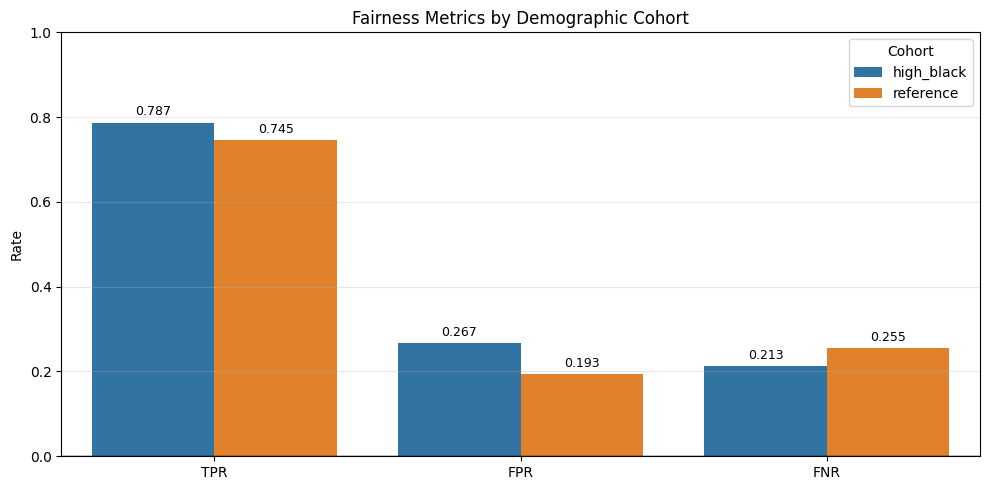

In [17]:
# 10) Grouped bar chart of TPR/FPR/FNR by cohort
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = pd.DataFrame(
    [
        {"Cohort": "high_black", "TPR": metrics_high_black["TPR"], "FPR": metrics_high_black["FPR"], "FNR": metrics_high_black["FNR"]},
        {"Cohort": "reference", "TPR": metrics_reference["TPR"], "FPR": metrics_reference["FPR"], "FNR": metrics_reference["FNR"]},
    ]
)

long_df = plot_df.melt(id_vars=["Cohort"], var_name="Metric", value_name="Value")

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=long_df,
    x="Metric",
    y="Value",
    hue="Cohort",
)

ax.set_title("Fairness Metrics by Demographic Cohort")
ax.set_xlabel("")
ax.set_ylabel("Rate")
ax.axhline(0, color="black", linewidth=1)  # requested reference line
ax.grid(True, axis="y", alpha=0.3)
ax.legend(title="Cohort", loc="best")
ax.set_ylim(0, 1)

# Value labels on bars
for container in ax.containers:
    try:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)
    except Exception:
        # Fallback for older Matplotlib
        for bar in container:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


/tmp/ipykernel_10010/2057094274.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


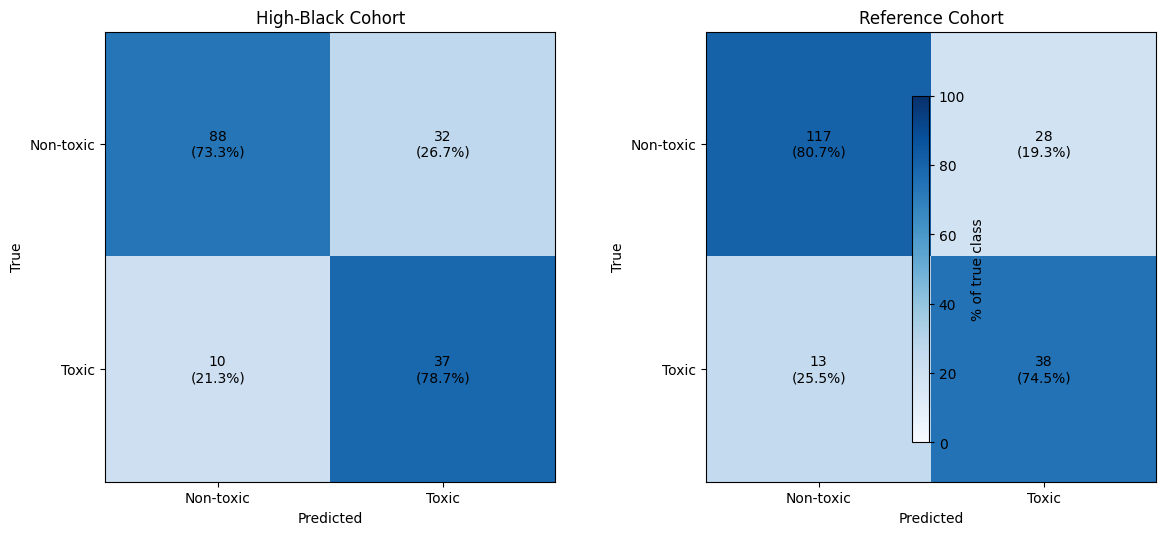

In [18]:
# 11) Confusion matrices side by side (counts + % annotations)
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix


def plot_confusion_matrix(ax, df: pd.DataFrame, title: str) -> None:
    y_true_local = df["toxic_label"].astype(int).to_numpy()
    y_pred_local = df["pred_label"].astype(int).to_numpy()

    cm = confusion_matrix(y_true_local, y_pred_local, labels=[0, 1]).astype(float)

    # Row-normalized percentages (percent of true class)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_pct = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums != 0) * 100.0

    im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)
    ax.set_title(title)

    labels = ["Non-toxic", "Toxic"]
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    # Annotate with counts + percentages
    for i in range(2):
        for j in range(2):
            count = int(cm[i, j])
            pct = cm_pct[i, j]
            ax.text(j, i, f"{count}\n({pct:.1f}%)", ha="center", va="center", fontsize=10)

    return im


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = plot_confusion_matrix(axes[0], high_black_df, "High-Black Cohort")
im1 = plot_confusion_matrix(axes[1], reference_df, "Reference Cohort")

fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.9, label="% of true class")
plt.tight_layout()
plt.show()


In [19]:
# 12) Summary table
try:
    from IPython.display import display
except Exception:
    display = None

summary_rows = [
    {
        "Cohort": "high_black",
        "Size": metrics_high_black["Size"],
        "TPR": metrics_high_black["TPR"],
        "FPR": metrics_high_black["FPR"],
        "FNR": metrics_high_black["FNR"],
        "Precision": metrics_high_black["Precision"],
        "Disparate_Impact": di_ratio,
    },
    {
        "Cohort": "reference",
        "Size": metrics_reference["Size"],
        "TPR": metrics_reference["TPR"],
        "FPR": metrics_reference["FPR"],
        "FNR": metrics_reference["FNR"],
        "Precision": metrics_reference["Precision"],
        "Disparate_Impact": 1.0,
    },
]

summary_df = pd.DataFrame(
    summary_rows,
    columns=["Cohort", "Size", "TPR", "FPR", "FNR", "Precision", "Disparate_Impact"],
)

print("Fairness audit summary:")
if display is not None:
    display(summary_df.style.format({"TPR": "{:.4f}", "FPR": "{:.4f}", "FNR": "{:.4f}", "Precision": "{:.4f}", "Disparate_Impact": "{:.4f}"}))
else:
    print(summary_df.round(4).to_string(index=False))


Fairness audit summary:


,Cohort,Size,TPR,FPR,FNR,Precision,Disparate_Impact
0,high_black,167,0.7872,0.2667,0.2128,0.5362,1.3810
1,reference,196,0.7451,0.1931,0.2549,0.5758,1.0000


In [20]:
# 13) Auto-generate updated interpretation (fills in latest results)
# This prints a ready-to-submit Markdown interpretation based on the metrics computed above.

try:
    from IPython.display import Markdown, display
except Exception:
    Markdown = None
    display = None

required_vars = [
    "metrics_high_black",
    "metrics_reference",
    "di_ratio",
    "THRESHOLD",
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        f"Missing {missing}. Run the cells above (predictions, cohorts, metrics, DI) before generating interpretation."
    )

# AIF360 variables are optional (only present if the AIF360 cell ran successfully)
spd_val = globals().get("spd", None)
eod_val = globals().get("eod", None)

# Compute disparities
metric_names = ["TPR", "FPR", "FNR", "Precision"]
diffs = {
    name: float(abs(metrics_high_black[name] - metrics_reference[name]))
    for name in metric_names
}
largest_metric = max(diffs, key=diffs.get)

hb_fpr = float(metrics_high_black["FPR"])
ref_fpr = float(metrics_reference["FPR"])
hb_fnr = float(metrics_high_black["FNR"])
ref_fnr = float(metrics_reference["FNR"])

# Over-/under-flagging narrative (primary focus: FPR for over-flagging)
over_flagging = "over-flags" if hb_fpr > ref_fpr else "does not over-flag"
under_flagging = "under-flags" if hb_fnr > ref_fnr else "does not under-flag"

# Directional explanations
fpr_direction = "higher" if hb_fpr > ref_fpr else "lower"
fnr_direction = "higher" if hb_fnr > ref_fnr else "lower"

# AIF360 helper strings
if spd_val is None:
    spd_line = "- Statistical parity difference (SPD): not computed (skip if AIF360 cell was not run)"
else:
    spd_line = f"- Statistical parity difference (SPD): {float(spd_val):.4f} (positive ⇒ high_black flagged more often)"

if eod_val is None:
    eod_line = "- Equal opportunity difference (EOD): not computed (skip if AIF360 cell was not run)"
else:
    eod_line = f"- Equal opportunity difference (EOD): {float(eod_val):.4f} (positive ⇒ higher TPR for high_black)"

md = f"""
## Bias audit interpretation (Part 2)

### Key disparity
The **largest disparity** between cohorts is in **{largest_metric}** (absolute gap = **{diffs[largest_metric]:.4f}**).

### Over-flagging vs under-flagging
- **False positives / over-flagging:** The `high_black` cohort has a **{fpr_direction} FPR** than the reference cohort.
  - FPR(high_black) = **{hb_fpr:.4f}**
  - FPR(reference)  = **{ref_fpr:.4f}**
  - Disparate impact (FPR ratio) = **{float(di_ratio):.4f}** (values > 1 indicate over-flagging)

- **False negatives / under-flagging:** The `high_black` cohort has a **{fnr_direction} FNR** than the reference cohort.
  - FNR(high_black) = **{hb_fnr:.4f}**
  - FNR(reference)  = **{ref_fnr:.4f}**

Overall, at the selected decision threshold (**THRESHOLD={float(THRESHOLD):.2f}**), the model **{over_flagging}** the `high_black` cohort via false positives and **{under_flagging}** it via missed toxicity.

### AIF360 parity/opportunity checks (optional)
{spd_line}
{eod_line}

### Real-world consequences
- If **FPR is higher** for `high_black`, more non-toxic comments from that cohort are wrongly flagged, leading to disproportionate removals/warnings and reduced trust.
- If **FNR is higher** for `high_black`, more toxic content targeted at/within that cohort may be missed, reducing safety and increasing exposure to harmful content.

### Connection to the 2019 Stanford NLP study scenario
These results illustrate the same risk highlighted in the scenario: even with a single global model and threshold, **error rates differ by demographic cohort**, producing unequal moderation outcomes (over-enforcement via false positives and/or under-enforcement via false negatives).
"""

if display is not None and Markdown is not None:
    display(Markdown(md))
else:
    print(md)



## Bias audit interpretation (Part 2)

### Key disparity
The **largest disparity** between cohorts is in **FPR** (absolute gap = **0.0736**).

### Over-flagging vs under-flagging
- **False positives / over-flagging:** The `high_black` cohort has a **higher FPR** than the reference cohort.
  - FPR(high_black) = **0.2667**
  - FPR(reference)  = **0.1931**
  - Disparate impact (FPR ratio) = **1.3810** (values > 1 indicate over-flagging)

- **False negatives / under-flagging:** The `high_black` cohort has a **lower FNR** than the reference cohort.
  - FNR(high_black) = **0.2128**
  - FNR(reference)  = **0.2549**

Overall, at the selected decision threshold (**THRESHOLD=0.40**), the model **over-flags** the `high_black` cohort via false positives and **does not under-flag** it via missed toxicity.

### AIF360 parity/opportunity checks (optional)
- Statistical parity difference (SPD): 0.0764 (positive ⇒ high_black flagged more often)
- Equal opportunity difference (EOD): 0.0421 (positive ⇒ higher TPR for high_black)

### Real-world consequences
- If **FPR is higher** for `high_black`, more non-toxic comments from that cohort are wrongly flagged, leading to disproportionate removals/warnings and reduced trust.
- If **FNR is higher** for `high_black`, more toxic content targeted at/within that cohort may be missed, reducing safety and increasing exposure to harmful content.

### Connection to the 2019 Stanford NLP study scenario
These results illustrate the same risk highlighted in the scenario: even with a single global model and threshold, **error rates differ by demographic cohort**, producing unequal moderation outcomes (over-enforcement via false positives and/or under-enforcement via false negatives).
